In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import display

In [2]:
data_path = "../data/processed/mieszkania_clean.csv"

df = pd.read_csv(data_path)

if "year_month" in df.columns:
    df["year_month"] = pd.to_datetime(df["year_month"])

print("Liczba rekordów:", df.shape[0])
print("Liczba kolumn:", df.shape[1])

df.head()

Liczba rekordów: 160974
Liczba kolumn: 36


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,hasStorageRoom,price,source_file,year_month,price_per_m2,relative_floor,m2_per_room,is_top_floor,is_ground_floor,building_height
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3,4,10,1980.0,53.378933,14.625296,...,yes,415000.0,apartments_pl_2023_08.csv,2023-08-01,6587.301587,0.400000,21.00,0,0,wysoki
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2,8,10,NaN,53.442692,14.559690,...,yes,395995.0,apartments_pl_2023_08.csv,2023-08-01,10999.861111,0.800000,18.00,0,0,wysoki
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3,2,3,NaN,53.452222,14.553333,...,no,565000.0,apartments_pl_2023_08.csv,2023-08-01,7737.606135,0.666667,24.34,0,0,niski
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3,2,3,NaN,53.435100,14.532900,...,yes,640000.0,apartments_pl_2023_08.csv,2023-08-01,7305.936073,0.666667,29.20,0,0,niski
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3,1,3,NaN,53.410278,14.503611,...,no,759000.0,apartments_pl_2023_08.csv,2023-08-01,11500.000000,0.333333,22.00,0,1,niski


In [3]:
if "price_per_m2" not in df.columns:
    df["price_per_m2"] = df["price"] / df["squareMeters"]

if "m2_per_room" not in df.columns:
    df["m2_per_room"] = df["squareMeters"] / df["rooms"]

if "relative_floor" not in df.columns:
    df["relative_floor"] = df["floor"] / df["floorCount"]

if "is_top_floor" not in df.columns:
    df["is_top_floor"] = (df["floor"] == df["floorCount"]).astype(int)

if "is_ground_floor" not in df.columns:
    df["is_ground_floor"] = (df["floor"] == 1).astype(int)

df[[
    "price",
    "squareMeters",
    "rooms",
    "floor",
    "floorCount",
    "price_per_m2",
    "m2_per_room",
    "relative_floor"
]].head()

,price,squareMeters,rooms,floor,floorCount,price_per_m2,m2_per_room,relative_floor
0,415000.0,63.00,3,4,10,6587.301587,21.00,0.400000
1,395995.0,36.00,2,8,10,10999.861111,18.00,0.800000
2,565000.0,73.02,3,2,3,7737.606135,24.34,0.666667
3,640000.0,87.60,3,2,3,7305.936073,29.20,0.666667
4,759000.0,66.00,3,1,3,11500.000000,22.00,0.333333


In [4]:
features_cluster = [
    "squareMeters",
    "rooms",
    "price_per_m2",
    "centreDistance",
    "floor",
    "floorCount",
    "relative_floor",
    "m2_per_room"
]

cluster_data = df.dropna(subset=features_cluster).copy()

X = cluster_data[features_cluster]

print("Liczba rekordów użytych do klasteryzacji:", X.shape[0])

X.head()

Liczba rekordów użytych do klasteryzacji: 160974


,squareMeters,rooms,price_per_m2,centreDistance,floor,floorCount,relative_floor,m2_per_room
0,63.00,3,6587.301587,6.53,4,10,0.400000,21.00
1,36.00,2,10999.861111,2.15,8,10,0.800000,18.00
2,73.02,3,7737.606135,3.24,2,3,0.666667,24.34
3,87.60,3,7305.936073,2.27,2,3,0.666667,29.20
4,66.00,3,11500.000000,4.07,1,3,0.333333,22.00


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.18278356,  0.33358795, -1.38515329,  0.78964556,  0.26369327,
         1.29954038, -0.82238716, -0.29974641],
       [-1.06716448, -0.75218327, -0.51480949, -0.76526639,  1.84367393,
         1.29954038,  0.54747961, -0.94917156],
       [ 0.64665316,  0.33358795, -1.15826447, -0.37831341, -0.52629706,
        -0.74020791,  0.09085735,  0.42328025],
       [ 1.32162511,  0.33358795, -1.2434081 , -0.72266606, -0.52629706,
        -0.74020791,  0.09085735,  1.47534899],
       [ 0.32166667,  0.33358795, -0.4161609 , -0.08366115, -0.92129223,
        -0.74020791, -1.05069829, -0.08327136]])

In [6]:
n_clusters = 6

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

cluster_data["cluster"] = kmeans.fit_predict(X_scaled)

df_clusters = df.copy()
df_clusters.loc[cluster_data.index, "cluster"] = cluster_data["cluster"]
df_clusters["cluster"] = df_clusters["cluster"].astype("Int64")

df_clusters["cluster"].value_counts().sort_index()

cluster
0    22955
1    21694
2    20212
3    22745
4    36839
5    36529
Name: count, dtype: Int64

In [7]:
cluster_summary = df_clusters.dropna(subset=["cluster"]).groupby("cluster").agg(
    liczba_ofert=("price", "count"),
    mediana_ceny=("price", "median"),
    mediana_ceny_m2=("price_per_m2", "median"),
    mediana_metrazu=("squareMeters", "median"),
    mediana_pokoi=("rooms", "median"),
    mediana_odleglosci_od_centrum=("centreDistance", "median"),
    mediana_pietra=("floor", "median"),
    mediana_liczby_pieter=("floorCount", "median"),
    mediana_wzglednego_pietra=("relative_floor", "median"),
    mediana_m2_na_pokoj=("m2_per_room", "median")
)

display(cluster_summary)

,liczba_ofert,mediana_ceny,mediana_ceny_m2,mediana_metrazu,mediana_pokoi,mediana_odleglosci_od_centrum,mediana_pietra,mediana_liczby_pieter,mediana_wzglednego_pietra,mediana_m2_na_pokoj
cluster,,,,,,,,,,
0,22955,799000.0,13950.073421,60.64,3.0,8.38,2.0,4.0,0.666667,22.000000
1,21694,1129000.0,11628.908605,95.00,4.0,3.14,3.0,4.0,0.750000,25.000000
2,20212,690000.0,14271.457086,50.00,3.0,4.44,8.0,10.0,0.800000,20.333333
3,22745,659000.0,15152.622921,50.10,2.0,2.84,3.0,4.0,0.600000,28.030000
4,36839,550000.0,10500.000000,50.75,3.0,2.95,3.0,4.0,1.000000,20.000000
5,36529,680000.0,13686.534216,49.99,3.0,3.63,1.0,5.0,0.250000,19.933333


In [8]:
def normalize_series(series):
    values = series.values.reshape(-1, 1)
    return pd.Series(
        MinMaxScaler().fit_transform(values).flatten(),
        index=series.index
    )


def nazwij_klastry(summary):
    summary = summary.copy()
    cluster_names = {}

    remaining = set(summary.index)

    premium_cluster = summary["mediana_ceny_m2"].idxmax()
    cluster_names[premium_cluster] = "premium"
    remaining.remove(premium_cluster)

    budget_cluster = summary.loc[list(remaining), "mediana_ceny_m2"].idxmin()
    cluster_names[budget_cluster] = "segment budżetowy"
    remaining.remove(budget_cluster)

    family_score = (
        normalize_series(summary.loc[list(remaining), "mediana_metrazu"]) +
        normalize_series(summary.loc[list(remaining), "mediana_pokoi"])
    )
    family_cluster = family_score.idxmax()
    cluster_names[family_cluster] = "rodzina z dziećmi"
    remaining.remove(family_cluster)

    student_score = (
        normalize_series(summary.loc[list(remaining), "mediana_metrazu"]) +
        normalize_series(summary.loc[list(remaining), "mediana_pokoi"])
    )
    student_cluster = student_score.idxmin()
    cluster_names[student_cluster] = "student / singiel"
    remaining.remove(student_cluster)

    senior_score = (
        normalize_series(summary.loc[list(remaining), "mediana_pietra"]) +
        normalize_series(summary.loc[list(remaining), "mediana_wzglednego_pietra"])
    )
    senior_cluster = senior_score.idxmin()
    cluster_names[senior_cluster] = "senior / dostępne mieszkanie"
    remaining.remove(senior_cluster)

    for cluster_id in remaining:
        cluster_names[cluster_id] = "inwestycyjne / standardowe"

    return cluster_names

In [9]:
cluster_names = nazwij_klastry(cluster_summary)

cluster_names_df = pd.DataFrame({
    "cluster": list(cluster_names.keys()),
    "segment": list(cluster_names.values())
}).sort_values("cluster")

display(cluster_names_df)

df_clusters["segment"] = df_clusters["cluster"].map(cluster_names)

df_clusters[[
    "city",
    "price",
    "squareMeters",
    "rooms",
    "price_per_m2",
    "cluster",
    "segment"
]].head(10)

,cluster,segment
4,0,senior / dostępne mieszkanie
2,1,rodzina z dziećmi
5,2,inwestycyjne / standardowe
0,3,premium
1,4,segment budżetowy
3,5,student / singiel


,city,price,squareMeters,rooms,price_per_m2,cluster,segment
0,szczecin,415000.0,63.00,3,6587.301587,5,student / singiel
1,szczecin,395995.0,36.00,2,10999.861111,2,inwestycyjne / standardowe
2,szczecin,565000.0,73.02,3,7737.606135,4,segment budżetowy
3,szczecin,640000.0,87.60,3,7305.936073,1,rodzina z dziećmi
4,szczecin,759000.0,66.00,3,11500.000000,5,student / singiel
5,szczecin,499000.0,63.30,3,7883.096367,5,student / singiel
6,szczecin,370000.0,47.45,2,7797.681770,5,student / singiel
7,szczecin,629000.0,60.08,2,10469.374168,3,premium
8,szczecin,399000.0,47.76,2,8354.271357,2,inwestycyjne / standardowe
9,szczecin,325000.0,72.09,4,4508.253572,4,segment budżetowy


In [10]:
segment_counts = df_clusters["segment"].value_counts().reset_index()
segment_counts.columns = ["segment", "liczba_mieszkan"]

segment_counts["udzial_proc"] = (
    segment_counts["liczba_mieszkan"] /
    segment_counts["liczba_mieszkan"].sum() *
    100
).round(2)

display(segment_counts)

,segment,liczba_mieszkan,udzial_proc
0,segment budżetowy,36839,22.89
1,student / singiel,36529,22.69
2,senior / dostępne mieszkanie,22955,14.26
3,premium,22745,14.13
4,rodzina z dziećmi,21694,13.48
5,inwestycyjne / standardowe,20212,12.56


In [11]:
segment_summary = df_clusters.dropna(subset=["segment"]).groupby("segment").agg(
    liczba_ofert=("price", "count"),
    mediana_ceny=("price", "median"),
    mediana_ceny_m2=("price_per_m2", "median"),
    mediana_metrazu=("squareMeters", "median"),
    mediana_pokoi=("rooms", "median"),
    mediana_odleglosci_od_centrum=("centreDistance", "median"),
    mediana_pietra=("floor", "median"),
    mediana_liczby_pieter=("floorCount", "median"),
    mediana_m2_na_pokoj=("m2_per_room", "median")
).sort_values("liczba_ofert", ascending=False)

display(segment_summary)

,liczba_ofert,mediana_ceny,mediana_ceny_m2,mediana_metrazu,mediana_pokoi,mediana_odleglosci_od_centrum,mediana_pietra,mediana_liczby_pieter,mediana_m2_na_pokoj
segment,,,,,,,,,
segment budżetowy,36839,550000.0,10500.000000,50.75,3.0,2.95,3.0,4.0,20.000000
student / singiel,36529,680000.0,13686.534216,49.99,3.0,3.63,1.0,5.0,19.933333
senior / dostępne mieszkanie,22955,799000.0,13950.073421,60.64,3.0,8.38,2.0,4.0,22.000000
premium,22745,659000.0,15152.622921,50.10,2.0,2.84,3.0,4.0,28.030000
rodzina z dziećmi,21694,1129000.0,11628.908605,95.00,4.0,3.14,3.0,4.0,25.000000
inwestycyjne / standardowe,20212,690000.0,14271.457086,50.00,3.0,4.44,8.0,10.0,20.333333


In [12]:
distances = kmeans.transform(X_scaled)

similarity = 1 / (1 + distances)
similarity_percent = similarity / similarity.sum(axis=1, keepdims=True) * 100

segment_score_df = pd.DataFrame(
    similarity_percent,
    columns=[cluster_names[i] for i in range(n_clusters)],
    index=cluster_data.index
)

segment_score_df.head()

,senior / dostępne mieszkanie,rodzina z dziećmi,inwestycyjne / standardowe,premium,segment budżetowy,student / singiel
0,17.803685,14.821869,16.966827,14.355700,16.581315,19.470604
1,13.620867,11.821634,26.080015,14.900181,17.986107,15.591196
2,16.455935,19.356532,11.376684,15.655357,20.548568,16.606925
3,15.461773,22.839385,11.948632,16.917912,17.418935,15.413364
4,17.778543,16.029314,10.735186,15.245173,17.189987,23.021797


In [13]:
df_clusters["najlepsze_dopasowanie_proc"] = np.nan

df_clusters.loc[
    segment_score_df.index,
    "najlepsze_dopasowanie_proc"
] = segment_score_df.max(axis=1).round(1)


def top_3_segments(row):
    top = row.sort_values(ascending=False).head(3)

    return [
        f"{segment}: {score:.1f}%"
        for segment, score in top.items()
    ]


df_clusters["top_3_segmenty"] = None

df_clusters.loc[
    segment_score_df.index,
    "top_3_segmenty"
] = segment_score_df.apply(top_3_segments, axis=1)


display(df_clusters[[
    "city",
    "price",
    "squareMeters",
    "rooms",
    "price_per_m2",
    "cluster",
    "segment",
    "najlepsze_dopasowanie_proc",
    "top_3_segmenty"
]].head(20))

,city,price,squareMeters,rooms,price_per_m2,cluster,segment,najlepsze_dopasowanie_proc,top_3_segmenty
0,szczecin,415000.0,63.00,3,6587.301587,5,student / singiel,19.5,"[student / singiel: 19.5%, senior / dostępne m..."
1,szczecin,395995.0,36.00,2,10999.861111,2,inwestycyjne / standardowe,26.1,"[inwestycyjne / standardowe: 26.1%, segment bu..."
2,szczecin,565000.0,73.02,3,7737.606135,4,segment budżetowy,20.5,"[segment budżetowy: 20.5%, rodzina z dziećmi: ..."
3,szczecin,640000.0,87.60,3,7305.936073,1,rodzina z dziećmi,22.8,"[rodzina z dziećmi: 22.8%, segment budżetowy: ..."
4,szczecin,759000.0,66.00,3,11500.000000,5,student / singiel,23.0,"[student / singiel: 23.0%, senior / dostępne m..."
5,szczecin,499000.0,63.30,3,7883.096367,5,student / singiel,20.3,"[student / singiel: 20.3%, segment budżetowy: ..."
6,szczecin,370000.0,47.45,2,7797.681770,5,student / singiel,22.8,"[student / singiel: 22.8%, premium: 18.0%, seg..."
7,szczecin,629000.0,60.08,2,10469.374168,3,premium,24.8,"[premium: 24.8%, segment budżetowy: 17.8%, sen..."
8,szczecin,399000.0,47.76,2,8354.271357,2,inwestycyjne / standardowe,27.1,"[inwestycyjne / standardowe: 27.1%, segment bu..."
9,szczecin,325000.0,72.09,4,4508.253572,4,segment budżetowy,20.8,"[segment budżetowy: 20.8%, rodzina z dziećmi: ..."


In [14]:
segment_city = df_clusters.dropna(subset=["segment"]).groupby(["city", "segment"]).agg(
    liczba_mieszkan=("price", "count"),
    mediana_ceny=("price", "median"),
    mediana_ceny_m2=("price_per_m2", "median"),
    mediana_metrazu=("squareMeters", "median")
).reset_index()

city_total = df_clusters.groupby("city").agg(
    liczba_mieszkan_w_miescie=("price", "count")
).reset_index()

segment_city = segment_city.merge(city_total, on="city", how="left")

segment_city["udzial_segmentu_w_miescie_proc"] = (
    segment_city["liczba_mieszkan"] /
    segment_city["liczba_mieszkan_w_miescie"] *
    100
).round(2)

display(segment_city.sort_values(
    ["city", "udzial_segmentu_w_miescie_proc"],
    ascending=[True, False]
).head(30))

,city,segment,liczba_mieszkan,mediana_ceny,mediana_ceny_m2,mediana_metrazu,liczba_mieszkan_w_miescie,udzial_segmentu_w_miescie_proc
3,bialystok,segment budżetowy,1134,444250.0,8508.196721,51.50,2184,51.92
4,bialystok,student / singiel,613,461999.0,9409.072554,54.40,2184,28.07
0,bialystok,inwestycyjne / standardowe,223,480000.0,9347.826087,50.23,2184,10.21
1,bialystok,premium,143,420000.0,10198.019802,51.00,2184,6.55
2,bialystok,rodzina z dziećmi,71,659000.0,7322.222222,83.10,2184,3.25
8,bydgoszcz,segment budżetowy,3647,365000.0,7497.850387,49.00,7719,47.25
9,bydgoszcz,student / singiel,1507,389900.0,8508.821855,48.63,7719,19.52
7,bydgoszcz,rodzina z dziećmi,1055,649000.0,6696.202532,94.00,7719,13.67
6,bydgoszcz,premium,919,285000.0,7985.697259,32.03,7719,11.91
5,bydgoszcz,inwestycyjne / standardowe,591,369000.0,7848.484848,47.50,7719,7.66


In [15]:
dominant_segment_by_city = (
    segment_city
    .sort_values(["city", "liczba_mieszkan"], ascending=[True, False])
    .drop_duplicates("city")
    .sort_values("udzial_segmentu_w_miescie_proc", ascending=False)
)

display(dominant_segment_by_city)

,city,segment,liczba_mieszkan,mediana_ceny,mediana_ceny_m2,mediana_metrazu,liczba_mieszkan_w_miescie,udzial_segmentu_w_miescie_proc
60,radom,segment budżetowy,1345,339000.0,6234.375000,53.87,2436,55.21
13,czestochowa,segment budżetowy,1237,320000.0,6320.907618,50.86,2297,53.85
3,bialystok,segment budżetowy,1134,444250.0,8508.196721,51.50,2184,51.92
8,bydgoszcz,segment budżetowy,3647,365000.0,7497.850387,49.00,7719,47.25
65,rzeszow,segment budżetowy,651,499000.0,9693.558474,56.71,1492,43.63
48,lublin,segment budżetowy,1952,496250.0,8829.787234,56.81,4624,42.21
42,lodz,segment budżetowy,4293,358700.0,7599.099879,46.00,12378,34.68
54,poznan,segment budżetowy,1932,559000.0,10593.220339,53.00,6248,30.92
70,szczecin,segment budżetowy,1596,469000.0,8474.820144,56.00,5234,30.49
30,katowice,segment budżetowy,1262,395000.0,7625.000000,51.00,4419,28.56


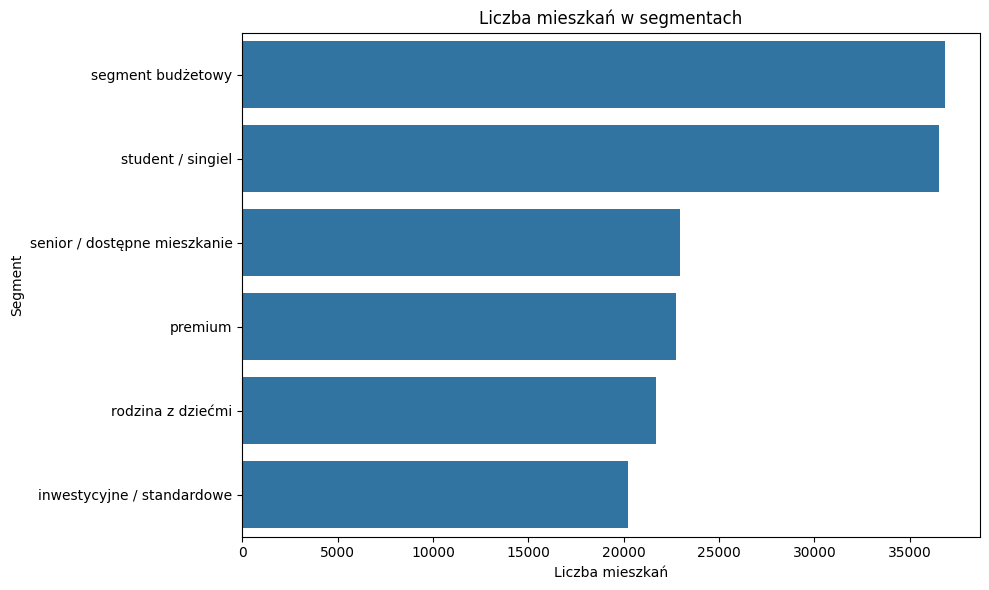

In [16]:
os.makedirs("../figures", exist_ok=True)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_counts,
    x="liczba_mieszkan",
    y="segment"
)

plt.title("Liczba mieszkań w segmentach")
plt.xlabel("Liczba mieszkań")
plt.ylabel("Segment")

plt.tight_layout()
plt.savefig("../figures/segmenty_liczba_mieszkan.png", dpi=300)
plt.show()

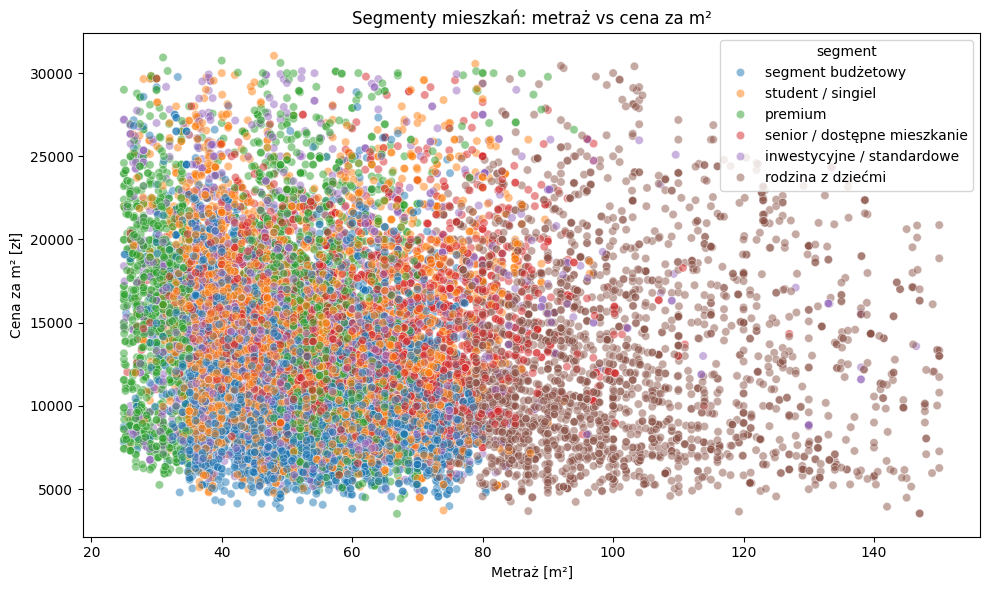

In [17]:
plot_sample = df_clusters.dropna(subset=["segment"]).sample(
    n=min(20000, df_clusters.dropna(subset=["segment"]).shape[0]),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x="squareMeters",
    y="price_per_m2",
    hue="segment",
    alpha=0.5
)

plt.title("Segmenty mieszkań: metraż vs cena za m²")
plt.xlabel("Metraż [m²]")
plt.ylabel("Cena za m² [zł]")

plt.tight_layout()
plt.savefig("../figures/segmenty_metraz_cena_m2.png", dpi=300)
plt.show()

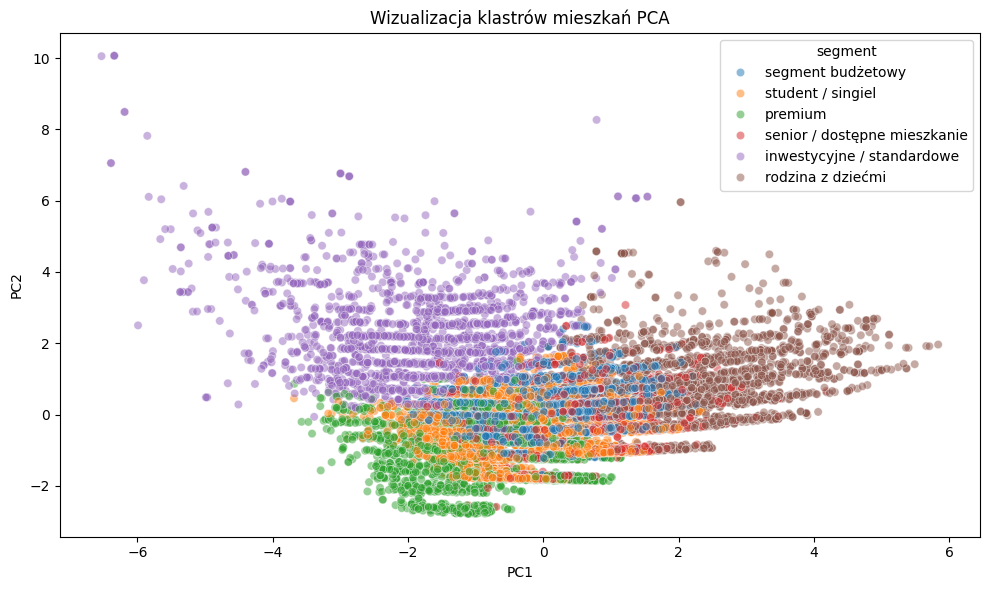

In [18]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "segment": cluster_data["cluster"].map(cluster_names)
}, index=cluster_data.index)

pca_plot_sample = pca_df.sample(
    n=min(20000, pca_df.shape[0]),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_plot_sample,
    x="PC1",
    y="PC2",
    hue="segment",
    alpha=0.5
)

plt.title("Wizualizacja klastrów mieszkań PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.savefig("../figures/segmenty_pca.png", dpi=300)
plt.show()

In [19]:
os.makedirs("../data/processed", exist_ok=True)

df_clusters.to_csv("../data/processed/segmentacja_klastry.csv", index=False)
cluster_summary.to_csv("../data/processed/podsumowanie_klastrow.csv")
segment_counts.to_csv("../data/processed/liczba_mieszkan_segmenty.csv", index=False)
segment_summary.to_csv("../data/processed/charakterystyka_segmentow.csv")
segment_city.to_csv("../data/processed/segmenty_w_miastach.csv", index=False)
dominant_segment_by_city.to_csv("../data/processed/dominujace_segmenty_w_miastach.csv", index=False)

print("Zapisano pliki wynikowe.")

Zapisano pliki wynikowe.
